<a href="https://colab.research.google.com/github/Hiero-o/cp-02-tritiack-sers/blob/main/cp_02_tritiack_sers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliotecas carregadas com sucesso.")

# Classificação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)



Bibliotecas carregadas com sucesso.


A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## 3. Carregar e explorar o CSV

Nesta etapa são analisadas a quantidade de registros, os tipos das colunas, os valores ausentes, a distribuição das classes e as estatísticas das variáveis de entrada.

In [7]:
dados = pd.read_csv(
    "aneel_classificacao_orange.csv",
    encoding="utf-8-sig"
)

print("Dimensões do conjunto:", dados.shape)

print("\nTipos das colunas:")
print(dados.dtypes)

print("\nValores ausentes:")
print(dados.isna().sum())

print("\nQuantidade por classe:")
display(dados["fonte"].value_counts())

print("\nPercentual por classe:")
display(
    dados["fonte"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nEstatísticas descritivas:")
display(dados.describe())

print("\nPrimeiras linhas:")
display(dados.head(10))

Dimensões do conjunto: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Quantidade por classe:


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200



Percentual por classe:


,proportion
fonte,
Hidráulica,38.08
Solar,30.96
Eólica,30.96



Estatísticas descritivas:


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000



Primeiras linhas:


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


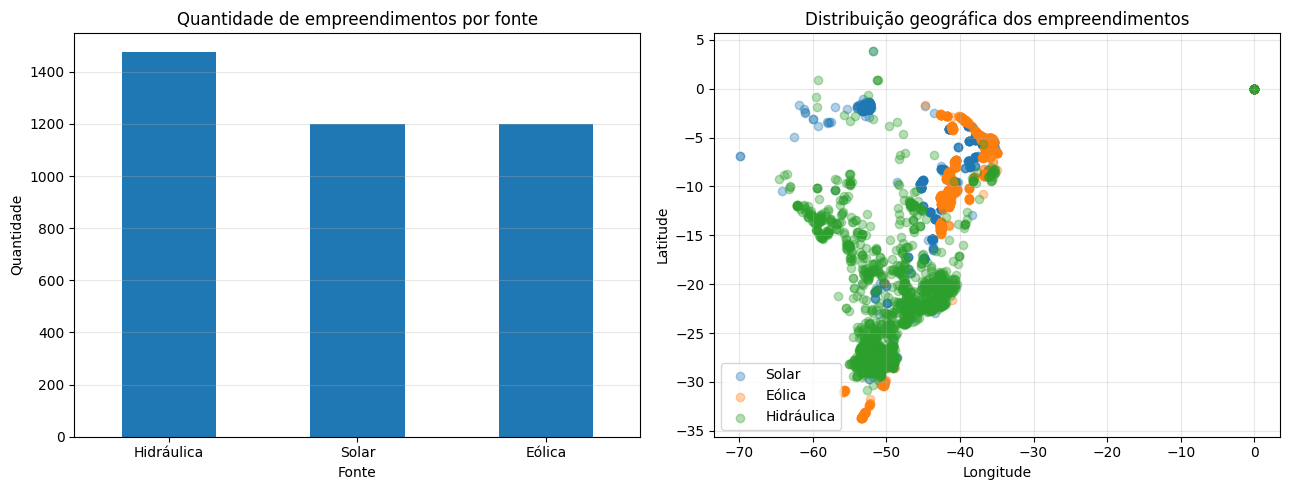

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dados["fonte"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Quantidade de empreendimentos por fonte")
axes[0].set_xlabel("Fonte")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

for classe in dados["fonte"].unique():
    grupo = dados[dados["fonte"] == classe]
    axes[1].scatter(
        grupo["longitude"],
        grupo["latitude"],
        alpha=0.35,
        label=classe
    )

axes[1].set_title("Distribuição geográfica dos empreendimentos")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Definição de X e y

As três variáveis utilizadas como entradas são `potencia_kw`, `latitude` e `longitude`.

A variável `fonte` é o alvo (`y`). Nenhuma informação que revele diretamente a classe, como `SigTipoGeracao`, nome do empreendimento ou CEG, é utilizada como entrada.

In [9]:
features = [
    "potencia_kw",
    "latitude",
    "longitude"
]

X = dados[features].copy()
y = dados["fonte"].copy()

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000



y:


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## 5. Divisão estratificada entre treino e teste

Será utilizada uma divisão de **80% para treino e 20% para teste**, com `random_state=42`.

O parâmetro `stratify=y` preserva aproximadamente a proporção das três classes nos dois conjuntos.

In [10]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Total: {len(X)}")
print(f"Treino: {len(X_treino)} ({len(X_treino) / len(X):.1%})")
print(f"Teste: {len(X_teste)} ({len(X_teste) / len(X):.1%})")

print("\nDistribuição das classes no treino:")
display(y_treino.value_counts(normalize=True).mul(100).round(2))

print("\nDistribuição das classes no teste:")
display(y_teste.value_counts(normalize=True).mul(100).round(2))

Total: 3876
Treino: 3100 (80.0%)
Teste: 776 (20.0%)

Distribuição das classes no treino:


,proportion
fonte,
Hidráulica,38.06
Solar,30.97
Eólica,30.97



Distribuição das classes no teste:


,proportion
fonte,
Hidráulica,38.14
Solar,30.93
Eólica,30.93


## 6. Treinamento dos três classificadores

Serão comparados:

- **KNN:** utiliza a proximidade dos exemplos para realizar a classificação;
- **Regressão Logística:** modelo linear para classificação multiclasses;
- **Random Forest:** conjunto de árvores de decisão capaz de representar relações não lineares.

A padronização é aplicada ao KNN e à Regressão Logística por meio de `Pipeline`. Assim, o `StandardScaler` é ajustado somente nos dados de treino, evitando vazamento de informações do teste.

In [11]:
modelos = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
}

resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)

    previsoes[nome] = y_pred

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_pred),
        "Precision (macro)": precision_score(
            y_teste, y_pred, average="macro", zero_division=0
        ),
        "Recall (macro)": recall_score(
            y_teste, y_pred, average="macro", zero_division=0
        ),
        "F1 (macro)": f1_score(
            y_teste, y_pred, average="macro", zero_division=0
        )
    })

comparacao = pd.DataFrame(resultados)

display(
    comparacao.style.format({
        "Accuracy": "{:.4f}",
        "Precision (macro)": "{:.4f}",
        "Recall (macro)": "{:.4f}",
        "F1 (macro)": "{:.4f}"
    })
)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.9652,0.9667,0.9636,0.9649
1,Regressão Logística,0.8235,0.8275,0.8200,0.8182
2,Random Forest,0.9742,0.9753,0.9727,0.9737


## 7. Matrizes de confusão

As matrizes de confusão mostram as classes reais nas linhas e as classes previstas nas colunas. Assim, é possível identificar quais fontes são classificadas corretamente e quais são mais confundidas pelos modelos.


Matriz de confusão — KNN
[[225   6   9]
 [  2 232   6]
 [  3   1 292]]


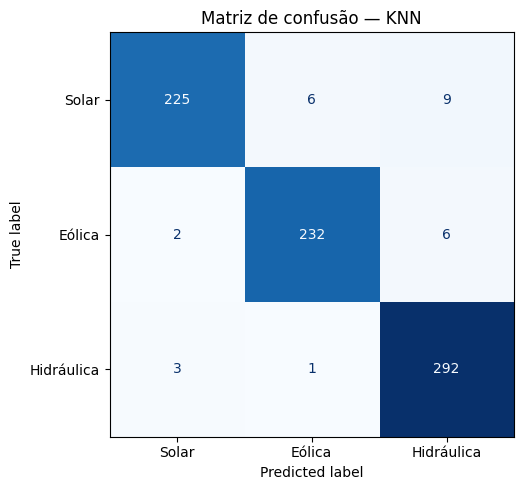


Matriz de confusão — Regressão Logística
[[166  55  19]
 [  8 216  16]
 [ 19  20 257]]


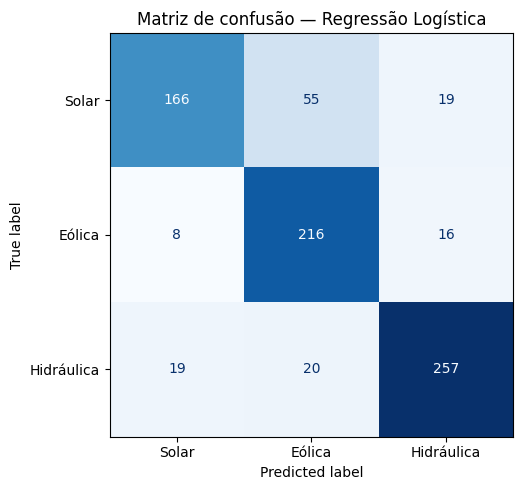


Matriz de confusão — Random Forest
[[226   7   7]
 [  1 236   3]
 [  0   2 294]]


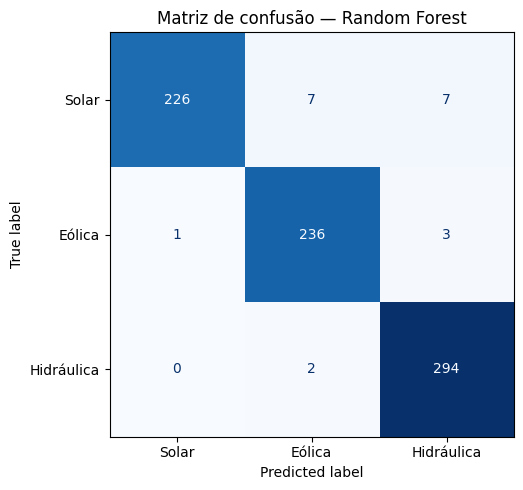

In [12]:
classes = ["Solar", "Eólica", "Hidráulica"]

for nome, y_pred in previsoes.items():
    matriz = confusion_matrix(
        y_teste,
        y_pred,
        labels=classes
    )

    print(f"\nMatriz de confusão — {nome}")
    print(matriz)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=classes
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusão — {nome}")
    plt.tight_layout()
    plt.show()

## 8. Relatório detalhado por classe

As métricas abaixo apresentam Precision, Recall e F1 individualmente para cada classe.

Na comparação geral, será utilizada **média macro**, que atribui o mesmo peso para Solar, Eólica e Hidráulica.

In [13]:
for nome, y_pred in previsoes.items():
    print("=" * 70)
    print(f"Modelo: {nome}")
    print("=" * 70)

    print(
        classification_report(
            y_teste,
            y_pred,
            labels=classes,
            target_names=classes,
            zero_division=0
        )
    )

Modelo: KNN
              precision    recall  f1-score   support

       Solar       0.98      0.94      0.96       240
      Eólica       0.97      0.97      0.97       240
  Hidráulica       0.95      0.99      0.97       296

    accuracy                           0.97       776
   macro avg       0.97      0.96      0.96       776
weighted avg       0.97      0.97      0.97       776

Modelo: Regressão Logística
              precision    recall  f1-score   support

       Solar       0.86      0.69      0.77       240
      Eólica       0.74      0.90      0.81       240
  Hidráulica       0.88      0.87      0.87       296

    accuracy                           0.82       776
   macro avg       0.83      0.82      0.82       776
weighted avg       0.83      0.82      0.82       776

Modelo: Random Forest
              precision    recall  f1-score   support

       Solar       1.00      0.94      0.97       240
      Eólica       0.96      0.98      0.97       240
  Hidráulica 

## 9. Comparação e interpretação dos resultados

A comparação considera Accuracy, Precision, Recall e F1 macro.

- **Accuracy:** proporção geral de previsões corretas.
- **Precision macro:** média da precisão obtida em cada classe.
- **Recall macro:** média da capacidade de identificar corretamente cada classe.
- **F1 macro:** média harmônica entre Precision e Recall de cada classe.

O uso da média `macro` dá o mesmo peso às três classes, independentemente da quantidade de exemplos de cada uma.

As matrizes de confusão permitem identificar quais classes apresentam maior quantidade de erros e quais pares de fontes são mais frequentemente confundidos.

In [14]:
melhor_indice = comparacao["F1 (macro)"].idxmax()
melhor_modelo = comparacao.loc[melhor_indice, "Modelo"]

print("Modelo com maior F1 macro:", melhor_modelo)

display(
    comparacao.sort_values(
        "F1 (macro)",
        ascending=False
    ).style.format({
        "Accuracy": "{:.4f}",
        "Precision (macro)": "{:.4f}",
        "Recall (macro)": "{:.4f}",
        "F1 (macro)": "{:.4f}"
    })
)

Modelo com maior F1 macro: Random Forest


,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
2,Random Forest,0.9742,0.9753,0.9727,0.9737
0,KNN,0.9652,0.9667,0.9636,0.9649
1,Regressão Logística,0.8235,0.8275,0.8200,0.8182


## 10. Limitações

Apesar da utilização de três classificadores e de métricas de avaliação, a fonte de um empreendimento não é determinada exclusivamente por sua potência e localização.

A potência pode assumir valores diferentes dentro de uma mesma tecnologia, enquanto uma mesma região geográfica pode possuir empreendimentos de diferentes fontes. Por isso, o modelo pode confundir classes que possuem características semelhantes nas três variáveis utilizadas.

Além disso, os dados representam o cadastro de empreendimentos da ANEEL e não a quantidade de energia efetivamente gerada. Nesta atividade não devem ser utilizadas informações que revelem diretamente a classe, como a sigla do tipo de geração, nome, CEG ou descrição da fonte.

## 11. Conclusão

Nesta tarefa foi desenvolvido um problema de classificação multiclasses utilizando dados de empreendimentos da ANEEL. O objetivo foi verificar se a potência outorgada e a localização de um empreendimento são suficientes para classificar sua fonte como Solar, Eólica ou Hidráulica.

Foram treinados três algoritmos diferentes — KNN, Regressão Logística e Random Forest — utilizando a mesma divisão estratificada de treino e teste. Os modelos foram comparados por Accuracy, Precision, Recall e F1, utilizando média macro, além das matrizes de confusão.

A análise das métricas permite comparar o comportamento dos modelos, enquanto as matrizes de confusão mostram quais classes apresentam maior dificuldade de classificação. Os resultados também evidenciam uma limitação importante: potência e localização, sozinhas, não representam todas as características necessárias para identificar com precisão a tecnologia de geração de um empreendimento.

Portanto, o exercício demonstra a aplicação prática de técnicas de aprendizado de máquina para classificação, desde a preparação dos dados até o treinamento, avaliação e interpretação dos resultados.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [16]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)